In [2]:
# !pip install thefuzz

/Users/adamoentoro/miniconda3/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:1632: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(


Detected intent: ingredient_search
Target recipe: None
Ingredients: ['chicken', 'eggs']


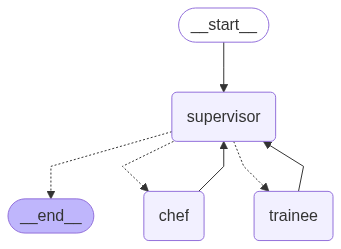

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	chef(chef)
	trainee(trainee)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	chef --> supervisor;
	supervisor -.-> __end__;
	supervisor -.-> chef;
	supervisor -.-> trainee;
	trainee --> supervisor;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	chef(chef)
	trainee(trainee)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	chef --> supervisor;
	supervisor -.-> __end__;
	supervisor -.-> chef;
	supervisor -.-> trainee;
	trainee --> supervisor;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



=== Current State ===
Phase: introduction
Step: 1

=== Current State ===
Phase: recipe_selection
Step: 1

=== Current

Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '']


KeyboardInterrupt: 

In [9]:
import json
import re
import time
from anthropic import APIError
import operator
from datetime import datetime
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_xai import ChatXAI
from langchain_anthropic import ChatAnthropic
from langchain_core.tracers.context import tracing_v2_enabled
from langsmith import traceable
import uuid
from langsmith import Client
from langsmith.run_helpers import get_current_run_tree
from langchain_community.callbacks import get_openai_callback
import pandas as pd
import ast
from langchain_core.pydantic_v1 import BaseModel, Field
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from __future__ import annotations
from typing import Annotated, TypedDict, List
from langgraph.graph.message import add_messages
from typing import Annotated
from operator import itemgetter  # For taking the last value
from langchain_core.messages import BaseMessage  # Add this import
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    AIMessage,
    SystemMessage
)
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict
from sentence_transformers import SentenceTransformer
import numpy as np
import ast
import faiss
from sklearn.decomposition import PCA
from langsmith import traceable
from langsmith.run_helpers import get_current_run_tree
from langchain_core.messages import HumanMessage
import matplotlib.pyplot as plt
from thefuzz import process
recipes_df = pd.read_csv("/Users/adamoentoro/Documents/GitHub/llm_conversation/cooking_assistant/data/recipes/13k-recipes.csv")

def build_recipe_faiss_index(recipes_df, model, ingredient_col='Cleaned_Ingredients'):
    """
    Build a FAISS index for recipe ingredient lists.
    Returns the FAISS index and the embeddings array.
    """
    # Prepare ingredient text for each recipe
    ingredient_texts = recipes_df[ingredient_col].apply(lambda ings: ', '.join(ast.literal_eval(ings)))
    # Generate embeddings
    recipe_embeddings = model.encode(ingredient_texts.tolist(), convert_to_numpy=True)
    # Get embedding dimension
    embedding_dim = recipe_embeddings.shape[1]
    # Build FAISS index
    recipe_index = faiss.IndexFlatL2(embedding_dim)
    recipe_index.add(recipe_embeddings)
    return recipe_index, recipe_embeddings

def build_ingredient_faiss_index(recipes_df, model, ingredient_col='Cleaned_Ingredients'):
    """
    Build a FAISS index for unique ingredients across all recipes.
    Returns the FAISS index, the embeddings array, and the list of unique ingredients.
    """
    # Collect all unique ingredients
    unique_ingredients = set()
    for ingr_list in recipes_df[ingredient_col]:
        unique_ingredients.update(ast.literal_eval(ingr_list))
    unique_ingredients = list(unique_ingredients)
    # Generate embeddings
    ingredient_embeddings = model.encode(unique_ingredients, convert_to_numpy=True)
    # Get embedding dimension
    embedding_dim = ingredient_embeddings.shape[1]
    # Build FAISS index
    ingredient_index = faiss.IndexFlatL2(embedding_dim)
    ingredient_index.add(ingredient_embeddings)
    return ingredient_index, ingredient_embeddings, unique_ingredients


from rdflib import Graph, Namespace, URIRef
from rdflib.namespace import RDFS
# Replace Food2Vec with a Sentence Transformer
from sentence_transformers import SentenceTransformer

# Initialize model (use food-specific if available)
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')  # General-purpose
# model = SentenceTransformer('flax-sentence-embeddings/recipe-clip')  # Food-optimized
recipe_index, recipe_embeddings = build_recipe_faiss_index(recipes_df, model)
ingredient_index, ingredient_embeddings, unique_ingredients = build_ingredient_faiss_index(recipes_df, model)
# # Assume recipe_embeddings is your numpy array of shape (n_recipes, embedding_dim)
# pca = PCA(n_components=2)
# reduced = pca.fit_transform(recipe_embeddings)

# plt.figure(figsize=(10, 8))
# plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5)
# plt.title("Recipe Embeddings (PCA 2D)")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.show()


# print("Recipes in FAISS index:", recipe_index.ntotal)
# print("Ingredients in FAISS index:", ingredient_index.ntotal)

# For recipes
# test_results = get_recipes_by_ingredients_faiss(['beef'], recipes_df, model, recipe_index, k=10)
# print(test_results[['Title', 'similarity']])

# For ingredient substitution
# test_subs = find_ingredient_substitutes('chicken', model, ingredient_index, unique_ingredients, k=3)
# print(test_subs)


class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]  # âœ… Use LangGraph's message reducer
    phase: Annotated[str, lambda _, x: x]
    max_retries: Annotated[int, lambda _, x: x]
    current_agent: Annotated[str, lambda _, x: x]
    user_profile: dict
    step_idx: int
    same_step_turns: int
    selected_recipe: dict | None
    chef_agent: 'ChefAgent'
    trainee_agent: 'TraineeAgent' 
    user_query: str | None
    clarified_topics: list[str]
    current_recipe: Annotated[dict | None, lambda _, x: x]  # Track selected recipe
    adjusted_ingredients: Annotated[dict, lambda _, x: x]


 # Changed from CookingState
def supervisor_router(state: State) -> str:
    if state.get("max_retries", 0) >= 3:
        return END
    
    phase = state["phase"]
    last_agent = state.get("current_agent")
    
    if phase == "chef_turn" and last_agent == "chef":
        state["max_retries"] += 1
    elif phase == "trainee_turn" and last_agent == "trainee":
        state["max_retries"] += 1
    else:
        state["max_retries"] = 0

    # Clear routing logic
    return {
        "introduction": "chef",
        "recipe_selection": "chef", 
        "chef_turn": "trainee",
        "trainee_turn": "chef",
        "done": END
    }.get(phase, END)




def supervisor_node(state: State):
    phase = state["phase"]
    if state.get("retries", 0) >= 3:
        state["phase"] = "done"
        return state

    if phase == "introduction":
        state["phase"] = "recipe_selection"
    if state.get("detected_intent") == "substitution":
        state["phase"] = "substitution"
    elif phase == "recipe_selection":
        if state.get("selected_recipe"):
            state["phase"] = "ingredient_check"  # or next logical phase
        else:
            state["phase"] = "recipe_selection"
    elif phase == "chef_turn":
        state["phase"] = "trainee_turn" if state.get("selected_recipe") else "recipe_selection"
    elif phase == "trainee_turn":
        state["phase"] = "chef_turn" if state.get("selected_recipe") else "recipe_selection"

    return state






def steps_from_recipe(state: State) -> list[str]:
    if not state.get("selected_recipe"):
        return []
    instructions = state["selected_recipe"].get("Instructions", "")
    if not instructions:
        return []
    return [s.strip() for s in re.split(r'\n+|\d+\.', instructions) if s.strip()]


# In chef_node:
def chef_node(state: State):
    phase = state["phase"]
    try:
        if phase == "introduction":
            response = state["chef_agent"].respond(
                state["messages"],
                "Introduce yourself as ChefAI, your friendly cooking assistant. Ask the user what they'd like to do: find a specific recipe, get similar recipes, or find recipes by ingredients."
            )
            state["messages"].append(AIMessage(content=response))
            state["phase"] = "recipe_selection"
            return state
            
        if phase == "substitution":
            intent = state.get("last_intent")
            recipe = state.get("selected_recipe")
            # 1. FAISS Candidates
            faiss_subs = [sub for sub, _ in find_ingredient_substitutes(
                intent.substitute_for, model, ingredient_index, unique_ingredients, k=10
            )]
            # 2. LLM Ranking
            validated_subs = validate_with_llm(state["chef_agent"], intent.substitute_for, faiss_subs, recipe)
            # STORE THE SHORTLIST FOR LATER VALIDATION
            state["validated_substitutes"] = validated_subs
            msg = (
                f"ChefAI: For {intent.substitute_for} in {recipe['Title']}, the best substitutes are:\n"
                + "\n".join(f"- {sub}" for sub in validated_subs)
                + "\nWhich would you like to use?"
            )
            state["messages"].append(AIMessage(content=msg))
            state["phase"] = "await_substitution_choice"
            return state






        if phase == "await_substitution_choice":
            user_choice = get_user_input().strip()
            validated_subs = state.get("validated_substitutes", [])
            if user_choice.lower() in [s.lower() for s in validated_subs]:
                # Accept and apply substitution
                state["messages"].append(AIMessage(content=f"Great! We'll use {user_choice}."))
                state["phase"] = "ingredient_check"
            else:
                state["messages"].append(AIMessage(
                    content="Sorry, that's not a valid substitute. Please choose from the list."
                ))
            return state




            
        if phase == "ingredient_check":
            user_response = get_user_input()  # however you fetch user input
            intent = state["chef_agent"].detect_intent(user_response)
            if intent.intent_type == "substitution":
                # Store the intent for later use if needed
                state["last_intent"] = intent
                state["phase"] = "substitution"
                return state
            elif user_response.lower() in ["yes", "y"]:
                state["phase"] = "chef_turn"
                return state
            else:
        # Repeat ingredient prompt or handle "no"
                response = "Please gather all the ingredients before we start. Let me know when you're ready!"
                state["messages"].append(AIMessage(content=response))
                return state

        # General validation
        if phase in ["chef_turn", "ingredient_check"] and not state.get("selected_recipe"):
            response = "No recipe selected yet. Please select a recipe to continue."
            state["messages"].append(AIMessage(content=response))
            state["phase"] = "recipe_selection"
            return state

        if phase == "recipe_selection":
            try:
                response = state["chef_agent"].select_recipe(state["user_query"], state)
                state["messages"].append(AIMessage(content=response))
                
                # If a recipe is selected, advance phase
                if state.get("selected_recipe"):
                    state["phase"] = "ingredient_check"  # or your next phase
                elif "Matching recipes:" in response or "Similar recipes:" in response:
                    state["phase"] = "user_select_recipe"
                else:
                    state["phase"] = "recipe_selection"
                    
                if "Error" in response:
                    state["retries"] = state.get("retries", 0) + 1
                return state
            except Exception as e:
                state["messages"].append(AIMessage(content=f"Error: {str(e)}"))
                state["phase"] = "recipe_selection"
                state["retries"] = state.get("retries", 0) + 1
                return state

        # ... rest of your phases ...
    except Exception as e:
        state["messages"].append(AIMessage(content=f"Chef encountered an error: {e}"))
        state["phase"] = "recipe_selection"
        return state

    return state



def trainee_node(state: State):
    phase = state["phase"]
    if phase == "trainee_turn" and not state.get("selected_recipe"):
        state["messages"].append(HumanMessage(content="No recipe selected."))
        state["phase"] = "recipe_selection"
        return state
    if phase in ("trainee_choose_recipe", "user_select_recipe"):
        recipe_list = extract_recipes_from_message(state["messages"][-1].content)
        print("DEBUG: Extracted recipe list:", recipe_list)
        chosen_recipe_name = state["trainee_agent"].choose_recipe(recipe_list, state)
        print("DEBUG: Chosen recipe name:", chosen_recipe_name)
        recipe = get_recipe_by_name(chosen_recipe_name, recipes_df)
        if not recipe and recipe_list:
            print("DEBUG: Fallback to first recipe in list.")
            recipe = get_recipe_by_name(recipe_list[0], recipes_df)
        if recipe:
            state["selected_recipe"] = recipe
            allergies = state["user_profile"].get("allergies", [])
            if contains_allergen(recipe['Cleaned_Ingredients'], allergies):
                state["phase"] = "allergy_warning"
            else:
                state["phase"] = "ingredient_check"
        else:
            state["phase"] = "recipe_selection"
        return state


    elif phase == "trainee_confirm_ingredients":
        response = state["trainee_agent"].confirm_ingredients(state)
        state["messages"].append(HumanMessage(content=response))
        if "yes" in response.lower():
            state["phase"] = "chef_turn"
        else:
            state["phase"] = "recipe_selection"
        return state


    elif phase == "trainee_turn":
        # Get the last chef message (the current step)
        chef_msgs = [msg for msg in state["messages"] if isinstance(msg, AIMessage)]
        last_chef_msg = chef_msgs[-1].content if chef_msgs else ""
        steps = steps_from_recipe(state)
        response = state["trainee_agent"].generate_response(last_chef_msg, len(steps))
        state["messages"].append(HumanMessage(content=response))
        # Only increment if the trainee says "next"
        if "next" in response.lower():
            state["step_idx"] += 1
            state["same_step_turns"] = 0
        else:
            state["same_step_turns"] = state.get("same_step_turns", 0) + 1
            # Optionally, force step progression after too many questions
            if state["same_step_turns"] > 2:
                state["step_idx"] += 1
                state["same_step_turns"] = 0
        state["phase"] = "chef_turn"
        return state



def extract_recipes_from_message(message):
    match = re.search(r"Matching recipes: (.+)", message)
    if match:
        return [r.strip() for r in match.group(1).split(",") if r.strip()]
    return []


import re

def extract_ingredient_names(candidates):
    names = []
    for item in candidates:
        # Match up to first colon or dash, or take the whole string if simple
        match = re.match(r"[\*\-]*\s*([A-Za-z\s]+)", item)
        if match:
            name = match.group(1).strip().lower()
            if name and name not in names:
                names.append(name)
    return names

def filter_substitutes(substitutes, original, clusters, ingredient_to_cluster):
    original_cluster = ingredient_to_cluster[original]
    return [s for s in substitutes if ingredient_to_cluster.get(s) == original_cluster and s != original]

def validate_formats_with_faiss(llm_subs, original, faiss_index, unique_ingredients, threshold=0.8):
    valid = []
    original_formats = [ing for ing in unique_ingredients if original in ing.lower()]
    
    for sub in llm_subs:
        # Find format matches using FAISS
        sub_embed = model.encode([sub], convert_to_numpy=True)
        D, I = faiss_index.search(sub_embed, 5)
        
        # Match existing ingredient formats
        for i, score in zip(I[0], D[0]):
            candidate = unique_ingredients[i]
            if any(fmt in candidate.lower() for fmt in original_formats):
                valid.append(candidate)
                break
                
    return list(set(valid))[:5]  # Return top 5 unique matches

def hybrid_ranking(agent, original, candidates, embeddings, unique_ingredients):
    # Semantic similarity weights
    original_idx = unique_ingredients.index(original)
    original_embed = embeddings[original_idx]
    
    scores = []
    for candidate in candidates:
        # FAISS similarity score
        candidate_idx = unique_ingredients.index(candidate)
        faiss_score = 1 / (1 + np.linalg.norm(original_embed - embeddings[candidate_idx]))
        
        # LLM compatibility score
        llm_score = get_llm_compatibility_score(agent, original, candidate)
        
        scores.append((candidate, 0.6*llm_score + 0.4*faiss_score))
    
    return [item[0] for item in sorted(scores, key=lambda x: x[1], reverse=True)]

def get_llm_compatibility_score(agent, original, substitute):
    prompt = f"""Rate compatibility between {original} and {substitute} (1-10) considering:
    - Flavor profile
    - Texture when cooked
    - Common substitution practices
    Return ONLY the number"""
    
    try:
        response = agent.llm.invoke([HumanMessage(content=prompt)]).content
        return float(response.strip())
    except:
        return 5.0  # Fallback score


def generate_llm_substitutes(agent, original_ingredient, recipe_title, instructions):
    prompt = f"""Suggest 5 culinary substitutes for {original_ingredient} in '{recipe_title}':
    Recipe Context: {instructions}
    Consider:
    - Flavor compatibility
    - Texture properties
    - Cooking behavior
    Return ONLY a comma-separated list"""
    
    response = agent.llm.invoke([HumanMessage(content=prompt)]).content
    return [s.strip() for s in response.split(",") if s.strip()]


def handle_substitution_request(state: State):
    intent = state["last_intent"]
    recipe = state["selected_recipe"]
    
    # 1. LLM Generates Culinary Substitutes
    llm_subs = generate_llm_substitutes(
        state["chef_agent"], 
        intent.substitute_for, 
        recipe['Title'],
        recipe['Instructions']
    )
    
    # 2. FAISS Validates Ingredient Formats
    validated_subs = validate_formats_with_faiss(
        llm_subs, 
        intent.substitute_for,
        ingredient_index,
        unique_ingredients
    )
    
    # 3. Hybrid Ranking (LLM + FAISS similarity)
    ranked_subs = hybrid_ranking(
        state["chef_agent"],
        intent.substitute_for,
        validated_subs,
        ingredient_embeddings,
        unique_ingredients
    )
    
    # 4. Update State and Response
    state["validated_substitutes"] = ranked_subs
    response = format_substitution_response(intent.substitute_for, ranked_subs)
    
    return append_response(state, response)



def validate_with_llm(chef_agent, original, candidates, recipe):
    prompt = (
        f"Given the recipe '{recipe['Title']}', rank these as substitutes for '{original}':\n"
        f"{', '.join(candidates)}\n"
        "Provide ONLY the top 3 as a bullet list, no explanations."
    )
    response = chef_agent.llm.invoke([HumanMessage(content=prompt)]).content
    # Extract only the bullet items
    validated = [
        line.lstrip('-•* ').strip()
        for line in response.split('\n')
        if line.strip().startswith(('-', '*', '•'))
    ]
    return validated


def build_cooking_graph():
    graph_builder = StateGraph(State)
    
    # Only 3 nodes: supervisor, chef, trainee
    graph_builder.add_node("supervisor", supervisor_node)
    graph_builder.add_node("chef", chef_node)
    graph_builder.add_node("trainee", trainee_node)
    
    # Start with supervisor
    graph_builder.add_edge(START, "supervisor")
    
    # Single conditional edge routing
    graph_builder.add_conditional_edges(
        "supervisor",
        supervisor_router,
        {
            "chef": "chef",
            "trainee": "trainee",
            END: END
        }
    )
    
    # Agents always return to supervisor
    graph_builder.add_edge("chef", "supervisor")
    graph_builder.add_edge("trainee", "supervisor")
    
    return graph_builder.compile()


class IntentDetection(BaseModel):
    """Identify user intent and extract key details"""
    intent_type: str = Field(..., description="Type of request: 'specific_recipe', 'similar_recipes', 'ingredient_search', 'substitution', 'recipe_selected'")
    target_recipe: str | None = Field(None, description="Recipe name if specified")
    ingredients: list[str] | None = Field(None, description="List of ingredients if provided")
    substitute_for: str | None = Field(None, description="Ingredient the user wants to substitute")
    substitute_with: str | None = Field(None, description="Ingredient the user wants to use instead")



client = Client()
runs = client.list_runs(project_name="run-traces")

# for run in runs:
#     print("Run name:", run.name)
#     print("Start time:", run.start_time)
#     print("End time:", run.end_time)
#     print("Duration (seconds):", (run.end_time - run.start_time).total_seconds())

class ChefAgent:
    def __init__(self, job_id, recipes_df, trainee_experience_log=None):
        # self.llm = ChatXAI(model="",
        #                     xai_api_key=os.environ["XAI_API_KEY"]
        # )
        self.llm = ChatOpenAI(model="gpt-4.1-mini", openai_api_key=os.environ["OPENAI_API_KEY"])
        self.structured_llm = ChatOpenAI(model="gpt-4.1-mini", openai_api_key=os.environ["OPENAI_API_KEY"]).with_structured_output(IntentDetection)
        self.job_id = job_id
        self.token_cost_log = []    
        self.recipes_df = recipes_df
        self.trainee_experience_log = trainee_experience_log
        self.system_message = self.build_system_message()

    def detect_intent(self, user_query: str) -> IntentDetection:
        prompt = f"""Analyze this cooking-related query:
    {user_query}

    Classify the intent:
    - 'specific_recipe' if the query matches or closely resembles the name of a known recipe
    - 'similar_recipes' if requesting variations
    - 'ingredient_search' if listing ingredients they have

    Extract recipe names or ingredients as needed."""
        return self.structured_llm.invoke(prompt)


        

    def select_recipe(self, user_query, state):
        try:
            # 1. Detect intent
            intent = self.detect_intent(user_query)
            
            # 2. Handle different intents
            if intent.intent_type == "specific_recipe":
                recipe = get_recipe_by_name(intent.target_recipe, recipes_df)
                if not recipe:
                    return "Recipe not found. Please try another."
                # Save selected recipe in state for future reference
                state["selected_recipe"] = recipe  # <-- Store the full recipe dict!
                return f"Selected recipe: {recipe['Title']}"
            
            elif intent.intent_type == "similar_recipes":
                similar = get_similar_recipes(intent.target_recipe, recipes_df)
                if similar.empty:
                    return "No similar recipes found."
                return f"Similar recipes: {', '.join(similar['Title'].tolist())}"
            
            elif intent.intent_type == "ingredient_search":
                matches = get_recipes_by_ingredients_faiss(
                    intent.ingredients, recipes_df, model, recipe_index, k=5
                )
                if matches.empty:
                    return "No recipes match those ingredients."
                return f"Matching recipes: {', '.join(matches['Title'].tolist())}"
            
            elif intent.intent_type == "substitution":
                # Use recipe from intent or fall back to session state
                recipe_name = intent.target_recipe or state.get("current_recipe")
                if recipe_name:
                    # valid_subs = substitute_ingredient(intent.substitute_for)
                    if intent.substitute_with and intent.substitute_with.lower() in [s.lower() for s in valid_subs]:
                        return (
                            f"Yes, you can use {intent.substitute_with} instead of {intent.substitute_for} in {recipe_name}. "
                            "Let me update the ingredient list and instructions for you."
                        )
                    else:
                        return (
                            f"{intent.substitute_with or 'That'} is not a typical substitute for {intent.substitute_for} in {recipe_name}. "
                            f"Based on food ontology, you can use these substitutes for {intent.substitute_for}: {', '.join(valid_subs)}. "
                            "Would you like to proceed with one of these?"
                        )
                else:
                    return (
                        "Please select a recipe first before requesting ingredient substitutions."
                    )


            else:
                return "Please clarify your request"
                
        except Exception as e:
            print(f"Recipe selection error: {e}")
            return "Error finding recipes. Please try again."


    def build_system_message(self):
        experience_level = self.trainee_experience_log.get('experience_level', 'unknown') if self.trainee_experience_log else 'unknown'
        allergies = self.trainee_experience_log.get('allergies', []) if self.trainee_experience_log else []
        preferred_cuisine = self.trainee_experience_log.get('preferred_cuisine', 'any') if self.trainee_experience_log else 'any'
        notes = self.trainee_experience_log.get('notes', '') if self.trainee_experience_log else ''

        allergy_str = ", ".join(allergies) if allergies else "none"

        experience_info = f"""
    User Profile:
    - Experience level: {experience_level}
    - Allergies: {allergy_str}
    - Preferred cuisine: {preferred_cuisine}
    - Notes: {notes}

    IMPORTANT INSTRUCTIONS:
    - NEVER suggest or proceed with any recipe or step that contains any of the user's allergens: {allergy_str}.
    - If the user requests a recipe with an allergen, gently warn them and suggest safe alternatives.
    - ALWAYS adapt your explanations to the user's experience level. For beginners, explain techniques, tools, and terminology in simple terms, and offer encouragement.
    - If the user has never performed a technique before (see notes), provide extra explanation and support when that technique arises.
    - Before each step, check if the user is comfortable and ready to proceed.
    """

        base_instructions = """
    Please follow these instructions carefully:

    1. Introduction:
    - Introduce yourself as ChefAI.
    - Briefly explain that you're here to help with recipe preparation.

    2. Recipe Confirmation:
    - Confirm the recipe name with the user.

    3. Ingredient Recall:
    - List all the ingredients required for the recipe.
    - Ask the user if they have all the ingredients ready.

    4. Step-by-Step Guidance:
    - Provide instructions one step at a time.
    - After each step, wait for the user to say "next" or ask a question before proceeding.
    - If the user asks a question, answer it thoroughly before continuing with the recipe steps.

    5. Completion:
    - When all steps are complete, congratulate the user and ask if they need any final advice.

    Before each interaction with the user, wrap your analysis in <recipe_analysis> tags to process the recipe, organize your thoughts, and prepare your response. In this analysis:
    - Break down the recipe into key components: ingredients, equipment needed, and cooking techniques.
    - Identify potential challenges or areas where users might need extra guidance.
    - Plan out how to present each step in a clear and concise manner.
    This will help you provide accurate and helpful guidance without revealing all instructions at once.

    Example interaction format:

    ChefAI: [Introduction and recipe confirmation]
    User: [Response]
    ChefAI: [List ingredients and ask if ready]
    User: [Response]
    ChefAI: [Provide first step]
    User: next
    ChefAI: [Provide next step]
    User: [Question]
    ChefAI: [Answer question]
    User: next
    ... (continue until recipe is complete)

    Remember to maintain a friendly and encouraging tone throughout the interaction. Begin your first response now by introducing yourself and confirming the recipe.
    """
        return SystemMessage(content=experience_info + base_instructions)


    @traceable(run_type="chain", name="Chef Response", metadata={"role": "chef"})
    def respond(self, conversation, prompt):
        # --- Intent detection and substitution logic ---
        intent = self.detect_intent(prompt)
        if intent.intent_type == "substitution":
            # Use the new LLM+ontology+FAISS substitution pipeline
            # Find the relevant recipe (from state or intent)
            recipe = None
            if hasattr(self, "state") and self.state.get("selected_recipe"):
                recipe = self.state["selected_recipe"]
            elif hasattr(self, "current_recipe") and self.current_recipe:
                recipe = self.current_recipe
            # Fallback: try to get by name
            elif intent.target_recipe:
                recipe = get_recipe_by_name(intent.target_recipe, self.recipes_df)
            if not recipe:
                return "Please select a recipe first before requesting ingredient substitutions."
            # Call your new pipeline
            updated_recipe = suggest_and_apply_substitution(self, intent.substitute_for, recipe)
            return f"Here's how you can substitute {intent.substitute_for} in '{recipe['Title']}':\n{updated_recipe}"


        # --- LLM fallback for all other intents ---
        run = get_current_run_tree()
        if run:
            run.metadata["job_id"] = self.job_id
            run.metadata["run_id"] = str(run.id)
        messages = [self.system_message] + conversation + [HumanMessage(content=prompt)]
        max_retries = 5
        base_delay = 1

        for attempt in range(max_retries):
            try:
                with get_openai_callback() as cb:
                    response = self.llm.invoke(messages).content.strip()
                    # Log token and cost info
                    self.token_cost_log.append({
                        "prompt_tokens": cb.prompt_tokens,
                        "completion_tokens": cb.completion_tokens,
                        "total_tokens": cb.total_tokens,
                        "cost": cb.total_cost,
                        "timestamp": datetime.now().isoformat(),
                        "prompt": prompt
                    })
                    update_running_totals(self.token_cost_log)
                    print(f"ChefAgent LLM call: {cb.total_tokens} tokens, ${cb.total_cost:.5f}")
                    return response
            except APIError as e:
                if "overloaded_error" in str(e):
                    delay = base_delay * (2 ** attempt)
                    print(f"OverloadedError: Retrying in {delay}s (attempt {attempt+1}/{max_retries})")
                    time.sleep(delay)
                else:
                    raise
        raise Exception("Max retries exceeded")

    def handle_substitution(self, intent, recipe):
        # Use the new hybrid pipeline
        updated_recipe = hybrid_substitution_pipeline(
            self, 
            intent.substitute_for,
            recipe
        )
        return parse_llm_recipe(updated_recipe)
        
        



class TraineeAgent:
    def __init__(self, job_id, trainee_experience_log=None, conversation_mode="mixed"):
        self.llm = ChatOpenAI(model="gpt-4.1-mini", openai_api_key=os.environ["OPENAI_API_KEY"])
        self.job_id = job_id
        self.current_step = 0
        self.recipe_data = None
        self.conversation_mode = conversation_mode
        self.token_cost_log = []
        self.trainee_experience_log = trainee_experience_log
        
    @traceable(run_type="chain", name="Trainee Response", metadata={"role": "trainee"})
    def generate_response(self, chef_message, num_steps):
        print("DEBUG: trainee_experience_log in agent:", self.trainee_experience_log)
        experience_level = self.trainee_experience_log
        notes = self.trainee_experience_log.get("notes", "")

        # Adjust question-asking behavior based on experience
        if experience_level == "advanced":
            question_instruction = (
                "ONLY ask a question if this step is ambiguous or unusually challenging for an expert cook. "
                "If everything is clear, say 'next'. Do NOT ask about basic techniques or substitutions."
            )
        elif experience_level == "intermediate":
            question_instruction = (
                "Ask a question if you are unsure about a technique or ingredient. "
                "Otherwise, say 'next'."
            )
        else:  # beginner
            question_instruction = (
                "If you have any doubt about the technique, ingredient, or process in this step, ask ONE SHORT, direct question. "
                "Otherwise, say 'next'."
            )

        # Optionally, use notes for further customization (e.g., never roasted a chicken)
        if notes and "never" in notes.lower():
            question_instruction += (
                f" You have noted: {notes}. If this step involves something you have never done, ask for extra explanation."
            )

        prompt = f"""
        You are a cooking trainee with experience level: {experience_level}.
        {f'Notes: {notes}' if notes else ''}
        Your goal is to act in accordance with your experience.

        Last chef instruction: {chef_message}
                
        

        INSTRUCTIONS:
        - Substitute the main ingredient of the recipe 
        - If you are advanced, only ask about unclear or complex steps. If everything is clear, say 'next'.
        - If you are a beginner, ask about anything you are unsure about.
        {question_instruction}
        """
        with get_openai_callback() as cb:
            response = self.llm.invoke([HumanMessage(content=prompt)])
            self.token_cost_log.append({
                "prompt_tokens": cb.prompt_tokens,
                "completion_tokens": cb.completion_tokens,
                "total_tokens": cb.total_tokens,
                "cost": cb.total_cost,
                "timestamp": datetime.now().isoformat(),
                "prompt": prompt
            })
            update_running_totals(self.token_cost_log)
            print(f"TraineeAgent LLM call: {cb.total_tokens} tokens, ${cb.total_cost:.5f}")
            return response.content.strip().lower()
        
    def confirm_ingredients(self, state: State) -> str:
        """TraineeAgent confirms ingredient readiness automatically"""
        try:
            # Get ingredients from last message
            ingredients_msg = state["messages"][-1].content
            allergies = state["user_profile"].get("allergies", [])
            
            # Check for allergens automatically
            has_allergen = any(allergen.lower() in ingredients_msg.lower() for allergen in allergies)
            
            if has_allergen:
                return f"I notice this recipe contains {', '.join(allergies)} which I'm allergic to. Can we find an alternative?"
            else:
                return "Yes, I have all the ingredients ready to proceed."
                
        except Exception as e:
            print(f"Error in confirm_ingredients: {e}")
            return "Yes, let's proceed with the recipe."
        
    def choose_recipe(self, recipe_list: list[str], state: State) -> str:
        """Automatically choose a recipe based on preferences"""
        try:
            preferences = state["user_profile"]
            preferred_cuisine = preferences.get("preferred_cuisine", "").lower()
            allergies = preferences.get("allergies", [])
            
            # Simple logic: pick first recipe that matches preferences and avoids allergens
            for recipe in recipe_list:
                # Check for preferred cuisine
                if preferred_cuisine and preferred_cuisine in recipe.lower():
                    # Check for allergens (basic check)
                    if not any(allergen.lower() in recipe.lower() for allergen in allergies):
                        return recipe
            
            # Fallback: return first recipe
            return recipe_list[0] if recipe_list else ""
            
        except Exception as e:
            print(f"Error choosing recipe: {e}")
            return recipe_list[0] if recipe_list else ""


def parse_steps(recipe_text):
    steps = [s.strip() for s in re.split(r'\n{2,}|\n', recipe_text) if s.strip()]
    return steps

def update_running_totals(log_list):
    total_tokens = 0
    total_cost = 0
    for entry in log_list:
        total_tokens += entry["total_tokens"]
        total_cost += entry["cost"]
        entry["cumulative_tokens"] = total_tokens
        entry["cumulative_cost"] = total_cost

def append_with_accrual(conversation, message, chef, trainee, combined_accrual):
    conversation.append(message)
    chef_cum = chef.token_cost_log[-1] if chef.token_cost_log else {"cumulative_tokens": 0, "cumulative_cost": 0}
    trainee_cum = trainee.token_cost_log[-1] if trainee.token_cost_log else {"cumulative_tokens": 0, "cumulative_cost": 0}
    combined_accrual.append({
        "chef_cumulative_tokens": chef_cum["cumulative_tokens"],
        "chef_cumulative_cost": chef_cum["cumulative_cost"],
        "trainee_cumulative_tokens": trainee_cum["cumulative_tokens"],
        "trainee_cumulative_cost": trainee_cum["cumulative_cost"],
        "overall_cumulative_tokens": chef_cum["cumulative_tokens"] + trainee_cum["cumulative_tokens"],
        "overall_cumulative_cost": chef_cum["cumulative_cost"] + trainee_cum["cumulative_cost"]
    })

# # Example experience log
# trainee_experience_log = {
#     "experience_level": "beginner",  # Options: 'beginner', 'intermediate', 'advanced'
#     "preferred_cuisine": "Italian",
#     "allergies": ["nuts"]
# }


from thefuzz import process

def get_recipe_by_name(name: str, df: pd.DataFrame) -> dict | None:
    recipe_titles = df['Title'].tolist()
    match, score = process.extractOne(name, recipe_titles)
    if score > 80:  # Adjust threshold as needed
        return df[df['Title'] == match].iloc[0].to_dict()
    return None


def get_similar_recipes(name: str, df: pd.DataFrame) -> pd.DataFrame:
    return df[df['Title'].str.lower().str.contains(name.lower(), na=False)].head(5)

def get_recipes_by_ingredients_faiss(ingredients, recipes_df, model, faiss_index, k=10):
    user_query = ', '.join(ingredients)
    user_embedding = model.encode([user_query], convert_to_numpy=True)
    D, I = faiss_index.search(user_embedding, k)
    results = recipes_df.iloc[I[0]].copy()
    results['similarity'] = 1 / (1 + D[0])  # Convert L2 distance to a similarity score
    # print(results)
    return results

def find_ingredient_substitutes(target_ingredient, model, ingredient_index, unique_ingredients, k=10):
    query_vec = model.encode([target_ingredient], convert_to_numpy=True)
    D, I = ingredient_index.search(query_vec, k)
    substitutes = [unique_ingredients[i] for i in I[0]]
    similarities = 1 / (1 + D[0])
    return list(zip(substitutes, similarities))




# # Load FoodOn ontology
# g = Graph()
# g.parse("foodon-base.owl", format="xml")  # Path to your FoodOn OWL file

# Define the FoodOn namespace
FOODON = Namespace("http://purl.obolibrary.org/obo/")

def get_sibling_classes(label):
    # Find the URI for the ingredient
    query_uri = None
    for s, p, o in g.triples((None, RDFS.label, None)):
        if o.lower() == label.lower():
            query_uri = s
            break
    if not query_uri:
        print(f"No class found for label: {label}")
        return []

    # Find the parent class
    parent = None
    for s, p, o in g.triples((query_uri, RDFS.subClassOf, None)):
        parent = o
        break
    if not parent:
        print(f"No parent class found for {label}")
        return []

    # Find all subclasses (siblings) of the parent
    siblings = []
    for s, p, o in g.triples((None, RDFS.subClassOf, parent)):
        if s != query_uri:
            sib_label = g.value(s, RDFS.label)
            if sib_label:
                siblings.append(str(sib_label))
    return siblings

# Example usage:
# print(get_sibling_classes("chicken"))  # Might return ["turkey", "duck", ...]

# def substitute_ingredient(ingredient_label, dietary_restrictions=None):
#     print(f"[KG SUBSTITUTION] Querying KG for substitutes for: {ingredient_label}")
#     ontology_subs = get_sibling_classes(ingredient_label)
    
#     if not ontology_subs:
#         print(f"[KG WARNING] No substitutes found for {ingredient_label}")
#         return []  # Return empty list to prevent errors
    
#     print(f"[KG SUBSTITUTION] Found substitutes: {ontology_subs}")
    
#     if dietary_restrictions:
#         ontology_subs = [sub for sub in ontology_subs if not is_subclass_of(sub, dietary_restrictions)]
    
#     return ontology_subs

def llm_suggest_substitute(chef_agent, ingredient, recipe_title):
    prompt = (
        f"In the recipe '{recipe_title}', what is the best substitute for '{ingredient}'? "
        "Only suggest plausible culinary alternatives."
    )
    return chef_agent.llm.invoke([HumanMessage(content=prompt)]).content.strip()

def llm_apply_substitution(chef_agent, recipe, original_ingredient, substitute, candidates):
    prompt = (
        f"Given the recipe '{recipe['Title']}', the user wants to substitute '{original_ingredient}' with '{substitute}'. "
        f"Other possible substitutes are: {', '.join(candidates)}. "
        "Update the ingredient list and instructions for this substitution. "
        "Adjust cooking times or tips if needed."
    )
    return chef_agent.llm.invoke([HumanMessage(content=prompt)]).content.strip()


def suggest_and_apply_substitution(chef_agent, ingredient, recipe):
    # Step 1: LLM generates candidate
    llm_candidate = llm_suggest_substitute(chef_agent, ingredient, recipe)
    
    # Step 2: Validate/expand
    faiss_subs = [sub for sub, _ in find_ingredient_substitutes(
        ingredient, model, ingredient_index, unique_ingredients, k=10  # ✅ Now using 'ingredient' parameter
    )]
    
    all_candidates = list(set([llm_candidate] + faiss_subs))
    
    # Step 3: LLM applies substitution
    updated_recipe = llm_apply_substitution(chef_agent, recipe, ingredient, llm_candidate, all_candidates)
    return updated_recipe




def detect_intent_with_fuzzy(user_query, recipes_df, chef):
    recipe_titles = recipes_df['Title'].tolist()
    # Only use fuzzy match for short queries
    if len(user_query.split()) <= 5:
        match, score = process.extractOne(user_query, recipe_titles)
        if score > 95:
            return IntentDetection(
                intent_type="specific_recipe",
                target_recipe=match,
                ingredients=None,
                substitute_for=None,
                substitute_with=None
            )
    # Otherwise, use LLM-based detection
    return chef.detect_intent(user_query)


def parse_llm_recipe(recipe_text):
    # Simple parsing assuming LLM outputs standard sections
    ingredients = []
    instructions = []
    in_ingredients = False
    in_instructions = False
    for line in recipe_text.splitlines():
        if "ingredient" in line.lower():
            in_ingredients = True
            in_instructions = False
            continue
        if "instruction" in line.lower() or "directions" in line.lower():
            in_ingredients = False
            in_instructions = True
            continue
        if in_ingredients:
            if line.strip().startswith("-"):
                ingredients.append(line.strip().lstrip("-").strip())
        if in_instructions:
            if line.strip() and not line.strip().lower().startswith("note"):
                instructions.append(line.strip())
    return {
        "Title": "Adapted Recipe",
        "Cleaned_Ingredients": str(ingredients),
        "Instructions": "\n".join(instructions)
    }



def contains_allergen(ingredients, allergies):
    try:
        ingredients_list = ast.literal_eval(ingredients)
    except Exception:
        ingredients_list = [ingredients]
    return any(allergen.lower() in " ".join(ingredients_list).lower() for allergen in allergies)

def visualize_graph(graph):
    """Visualize the LangGraph structure using built-in methods"""
    display(Image(graph.get_graph().draw_mermaid_png()))
    print(graph.get_graph().draw_mermaid())
    return graph.get_graph().draw_mermaid()

    
    # Initialize state
def automated_cooking_session(job_id, trainee_experience_log=None):
    chef = ChefAgent(job_id, recipes_df, trainee_experience_log)
    trainee = TraineeAgent(job_id, trainee_experience_log=trainee_experience_log)
    system_message = chef.system_message
    conversation = []
    combined_accrual = []
    interaction_log = []

    # Build and visualize the graph structure BEFORE user input
    graph = build_cooking_graph()
    # print("\n" + visualize_graph(graph) + "\n")  # <-- This will display the graph immediately

    # Now prompt the user
    user_query = input("What would you like to cook? ")
    initial_state = {
        "messages": [system_message],  # System prompt is first!
        "phase": "introduction",
        "user_profile": trainee_experience_log,
        "step_idx": 0,
        "retries": 0,
        "same_step_turns": 0,
        "selected_recipe": None,
        "chef_agent": chef,
        "trainee_agent": trainee,
        "user_query": user_query,
        "clarified_topics": []
    }

    intent = detect_intent_with_fuzzy(user_query, recipes_df, chef)
    print(f"Detected intent: {intent.intent_type}")
    print(f"Target recipe: {intent.target_recipe}")
    print(f"Ingredients: {intent.ingredients}")


    
    # Build and compile graph
    graph = build_cooking_graph()
    
    # Increase recursion limit and add debugging
    config = {"recursion_limit": 200}  # From 25 to 100
    
    # Print graph structure
    print("\n" + visualize_graph(graph) + "\n")
    final_state = None

    # Run conversation loop with debugging
    for output in graph.stream(initial_state, config=config, stream_mode="values"):
        print(f"\n=== Current State ===")
        print(f"Phase: {output.get('phase', 'unknown')}")
        print(f"Step: {output.get('step_idx', 0)+1}")
        
        # Print last chef message
        chef_msgs = [msg for msg in output.get("messages", []) if isinstance(msg, AIMessage)]
        if chef_msgs:
            print(f"\nChef: {chef_msgs[-1].content}")
        
        # Print last trainee message
        trainee_msgs = [msg for msg in output.get("messages", []) if isinstance(msg, HumanMessage)] 
        if trainee_msgs:
            print(f"Trainee: {trainee_msgs[-1].content}")
            
        # Check for completion
        if output.get("phase") == "done":
            final_state = output
            break

    if final_state is not None:
        save_conversation_to_json(job_id, final_state, chef, trainee)
    else:
        print("No completed conversation to save.")



    print("ChefAgent system prompt:\n", chef.system_message.content)

    # User selects query type
    # user_query = input("What would you like to cook? ")
    
    
    # Access fields directly
    print(f"Detected intent: {intent.intent_type}")
    print(f"Target recipe: {intent.target_recipe}")
    print(f"Ingredients: {intent.ingredients}")

    if intent.intent_type == "specific_recipe":
        selected_recipe = get_recipe_by_name(intent.target_recipe, recipes_df)
        if selected_recipe is None:
            print("No recipe found.")
            return
    elif intent.intent_type == "similar_recipes":
        similar = get_similar_recipes(intent.target_recipe, recipes_df)
        if similar.empty:
            print("No similar recipes found.")
            return
        print("Similar recipes found:")
        print(similar['Title'].to_list())
        user_choice = input("Which recipe do you want? ")
        selected_recipe = get_recipe_by_name(user_choice, recipes_df)
        if selected_recipe is None:
            print("No recipe found.")
            return
    elif intent.intent_type == "ingredient_search":
        matches = get_recipes_by_ingredients_faiss(
            intent.ingredients, recipes_df, model, recipe_index, k=5
        )
        if matches.empty:
            print("No recipes found for those ingredients.")
            return
        print("Recipes you can make:")
        print(matches['Title'].to_list())
        user_choice = input("Which recipe do you want? ")
        selected_recipe = get_recipe_by_name(user_choice, recipes_df)
        if selected_recipe is None:
            print("No recipe found.")
            return
    else:
        print("Please clarify your request")
        return


    # Now proceed with your step-by-step logic using selected_recipe
    initial_state["selected_recipe"] = selected_recipe
    recipe_text = selected_recipe['Instructions']
    steps = parse_steps(recipe_text)
    ingredients = selected_recipe['Cleaned_Ingredients']

    try:
        ingredients_list = ast.literal_eval(ingredients)
        if not isinstance(ingredients_list, list):
            ingredients_list = [ingredients]  # fallback: treat as single string
    except Exception:
        ingredients_list = [ingredients]  # fallback: treat as single string

    # 2. Chef lists ingredients and asks if trainee is ready
    ingredients_message = (
        f"Here are the ingredients you'll need for '{selected_recipe['Title']}':\n"
        + "\n".join(f"- {item}" for item in ingredients_list)
        + "\nDo you have all these ingredients ready? (yes/no)\n"
        "If you want to substitute any ingredient, just tell me (e.g., 'Can I use turkey instead of chicken?')."
    )

    print("\nChefAI:", ingredients_message)
    append_with_accrual(conversation, AIMessage(content=ingredients_message), chef, trainee, combined_accrual)

    # 3. Wait for trainee confirmation before proceeding
# 3. Wait for trainee confirmation before proceeding
    while True:
        yn_response = input("Do you have all these ingredients ready? (yes/no): ").strip().lower()
        if yn_response in ["yes", "y"]:
            # Now ask about substitutions
            sub_response = input(
                "Would you like to substitute any ingredient? (e.g., 'Can I use turkey instead of chicken?') If not, type 'no': "
            ).strip().lower()
            if sub_response in ["no", "n"]:
                print("Great! Let's proceed with the recipe.")
                break
            else:
                # Detect intent and process the substitution
                intent = chef.detect_intent(sub_response)
                if intent.intent_type == "substitution":
                    # Step 1: Generate a list of candidates (LLM + FAISS)
                    llm_candidates = generate_llm_substitutes(chef, intent.substitute_for, selected_recipe["Title"], selected_recipe["Instructions"])
                    faiss_subs = [sub for sub, _ in find_ingredient_substitutes(
                        intent.substitute_for, model, ingredient_index, unique_ingredients, k=10
                    )]
                    all_candidates = list(set(llm_candidates + faiss_subs))

                    print(f"ChefAI: Here are some substitutes for {intent.substitute_for}: {', '.join(all_candidates)}.")
                    chosen_sub = input("Which would you like to use? ").strip().lower()
                    while chosen_sub not in [s.lower() for s in all_candidates]:
                        print("Sorry, that's not a valid substitute. Please choose from the list.")
                        chosen_sub = input("Which would you like to use? ").strip().lower()

                    # Step 2: Now rewrite the recipe with the chosen substitute
                    updated_recipe = llm_apply_substitution(chef, selected_recipe, intent.substitute_for, chosen_sub, all_candidates)
                    print(f"ChefAI: Great! Here are your updated instructions:\n{updated_recipe}")
                    selected_recipe = parse_llm_recipe(updated_recipe)
                    break
                else:
                    print("Sorry, I didn't understand your substitution request. Please rephrase or type 'no' to continue.")
        elif yn_response in ["no", "n"]:
            print("Please gather all the ingredients before we start. Let me know when you're ready!")
        else:
            print("Please respond with 'yes' or 'no'.")



    # 5. Step-by-step guidance
    steps = parse_steps(recipe_text)
    for idx, step in enumerate(steps):
    # Chef's turn
        chef_step = chef.respond(conversation, f"Step {idx+1}: {step}\nExplain...")
        print(f"\nChef (Step {idx+1}):", chef_step)
        append_with_accrual(conversation, AIMessage(content=chef_step), chef, trainee, combined_accrual)

        # Trainee's turn
        trainee.current_step = idx
        trainee_msg = trainee.generate_response(chef_step, len(steps))
        print("\nTrainee:", trainee_msg)
        append_with_accrual(conversation, HumanMessage(content=trainee_msg), chef, trainee, combined_accrual)

    # Log interaction metrics
    interaction_log.append({
        "step": idx+1,
        "chef_tokens": chef.token_cost_log[-1]["total_tokens"],
        "trainee_tokens": trainee.token_cost_log[-1]["total_tokens"],
        "total_cost": chef.token_cost_log[-1]["cost"] + trainee.token_cost_log[-1]["cost"],
        "cumulative_tokens": chef.token_cost_log[-1]["cumulative_tokens"] + trainee.token_cost_log[-1]["cumulative_tokens"],
        "cumulative_cost": chef.token_cost_log[-1]["cumulative_cost"] + trainee.token_cost_log[-1]["cumulative_cost"]
    })

    # 6. End message
    chef_end = chef.respond(conversation, "Say cooking is complete and offer congratulations.")
    print("\nChef:", chef_end)
    conversation.append(AIMessage(content=chef_end))

    # 7. Save conversation to JSON

    

    conversation_log = []
    for i, m in enumerate(conversation):
        entry = {
            "role": "trainee" if isinstance(m, HumanMessage) else "chef",
            "content": m.content
        }
        if i < len(combined_accrual):
            entry.update(combined_accrual[i])
        conversation_log.append(entry)


    chef_total_tokens = sum(entry["total_tokens"] for entry in chef.token_cost_log)
    chef_total_cost = sum(entry["cost"] for entry in chef.token_cost_log)

    # Aggregate Trainee stats
    trainee_total_tokens = sum(entry["total_tokens"] for entry in trainee.token_cost_log)
    trainee_total_cost = sum(entry["cost"] for entry in trainee.token_cost_log)

    # Overall totals
    overall_total_tokens = chef_total_tokens + trainee_total_tokens
    overall_total_cost = chef_total_cost + trainee_total_cost

    # Print results
    print("\n=== Token and Cost Summary ===")
    print(f"ChefAgent:    {chef_total_tokens} tokens, ${chef_total_cost:.6f}")
    print(f"TraineeAgent: {trainee_total_tokens} tokens, ${trainee_total_cost:.6f}")
    print(f"TOTAL:        {overall_total_tokens} tokens, ${overall_total_cost:.6f}")


    last_chef = chef.token_cost_log[-1]
    print(f"ChefAgent running total: {last_chef['cumulative_tokens']} tokens, ${last_chef['cumulative_cost']:.6f}")

    last_trainee = trainee.token_cost_log[-1]
    print(f"TraineeAgent running total: {last_trainee['cumulative_tokens']} tokens, ${last_trainee['cumulative_cost']:.6f}")

    if 'combined_accrual' not in locals():
        combined_accrual = []

    # Get last chef and trainee cumulative totals (or 0 if none yet)
    chef_cum = chef.token_cost_log[-1] if chef.token_cost_log else {"cumulative_tokens": 0, "cumulative_cost": 0}
    trainee_cum = trainee.token_cost_log[-1] if trainee.token_cost_log else {"cumulative_tokens": 0, "cumulative_cost": 0}

    combined_accrual.append({
        "turn": len(combined_accrual) + 1,
        "chef_cumulative_tokens": chef_cum["cumulative_tokens"],
        "chef_cumulative_cost": chef_cum["cumulative_cost"],
        "trainee_cumulative_tokens": trainee_cum["cumulative_tokens"],
        "trainee_cumulative_cost": trainee_cum["cumulative_cost"],
        "overall_cumulative_tokens": chef_cum["cumulative_tokens"] + trainee_cum["cumulative_tokens"],
        "overall_cumulative_cost": chef_cum["cumulative_cost"] + trainee_cum["cumulative_cost"]
    })


    # Prepare summary for saving
    token_cost_summary = {
        "chef_total_tokens": chef_total_tokens,
        "chef_total_cost": chef_total_cost,
        "trainee_total_tokens": trainee_total_tokens,
        "trainee_total_cost": trainee_total_cost,
        "overall_total_tokens": overall_total_tokens,
        "overall_total_cost": overall_total_cost,
        "chef_turns": chef.token_cost_log,
        "trainee_turns": trainee.token_cost_log
    }

    with open(f"cooking_session_{job_id}_full_log.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "job_id": job_id,
                "conversation": conversation_log,
                "metrics": {
                    # "interactions": interaction_log,  # New per-interaction data
                    "chef_turns": chef.token_cost_log,
                    "trainee_turns": trainee.token_cost_log,
                }
            },
            f, indent=2, ensure_ascii=False
        )


import json
from datetime import datetime

def save_conversation_to_json(job_id, state, chef, trainee):
    conversation_log = []
    messages = state.get("messages", [])
    for i, m in enumerate(messages):
        entry = {
            "role": "trainee" if isinstance(m, HumanMessage) else "chef",
            "content": m.content,
            "timestamp": datetime.now().isoformat()
        }
        # Optionally, add token/cost info if available
        conversation_log.append(entry)

    # Optionally, add summary stats
    chef_total_tokens = sum(entry["total_tokens"] for entry in chef.token_cost_log)
    chef_total_cost = sum(entry["cost"] for entry in chef.token_cost_log)
    trainee_total_tokens = sum(entry["total_tokens"] for entry in trainee.token_cost_log)
    trainee_total_cost = sum(entry["cost"] for entry in trainee.token_cost_log)
    overall_total_tokens = chef_total_tokens + trainee_total_tokens
    overall_total_cost = chef_total_cost + trainee_total_cost

    summary = {
        "chef_total_tokens": chef_total_tokens,
        "chef_total_cost": chef_total_cost,
        "trainee_total_tokens": trainee_total_tokens,
        "trainee_total_cost": trainee_total_cost,
        "overall_total_tokens": overall_total_tokens,
        "overall_total_cost": overall_total_cost
    }

    # Save as JSON file with unique job_id
    with open(f"cooking_session_{job_id}_full_log.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "job_id": job_id,
                "conversation": conversation_log,
                "metrics": summary
            },
            f, indent=2, ensure_ascii=False
        )


# Usage with your recipe
if __name__ == "__main__":
    job_id = str(uuid.uuid4())
    trainee_experience_log = {
        "experience_level": "Advanced",
        "preferred_cuisine": "",
        "allergies": ["Chicken"],
        "notes": ""
    }
    with tracing_v2_enabled(project_name="run-traces", tags=[f"job_id:{job_id}"]):
        automated_cooking_session(job_id, trainee_experience_log=trainee_experience_log)